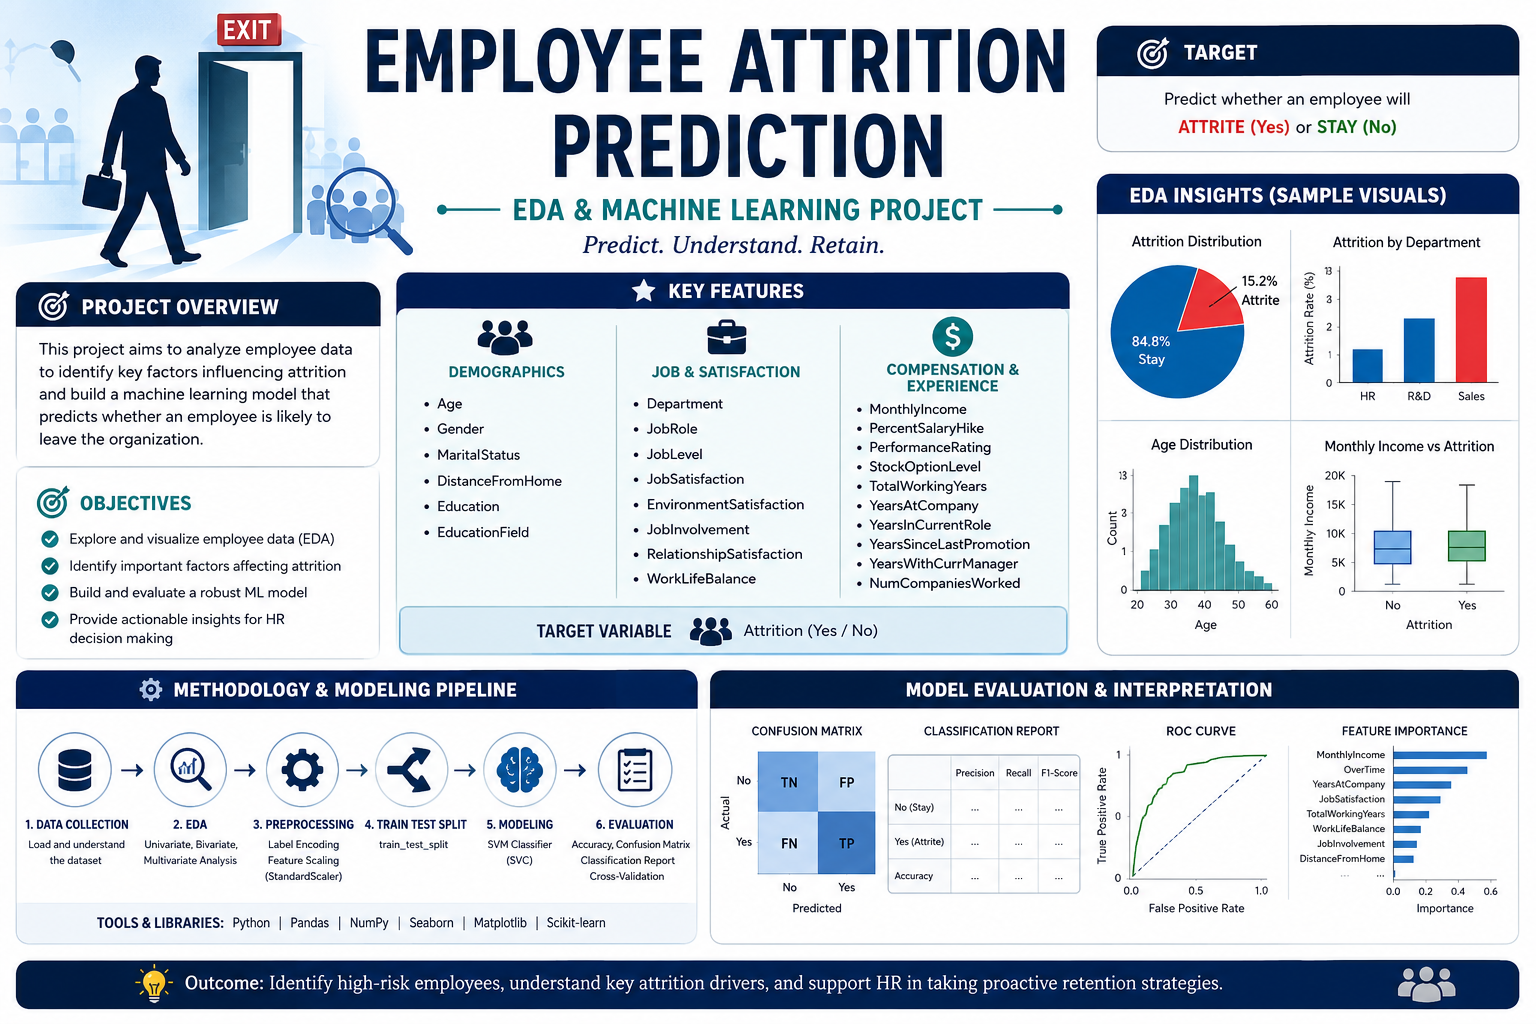

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_val_score


In [ ]:
import pandas as pd
df=pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.shape

(1470, 35)

In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop([
'EmployeeCount',
'EmployeeNumber',
'Over18',
'StandardHours'
],axis=1,inplace=True)

In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [ ]:
print(df["Attrition"].unique())
print(df["Gender"].unique())

['Yes' 'No']
['Female' 'Male']


In [ ]:
df["Attrition"]=df["Attrition"].map({"Yes":1,"No":0})
df["Gender"]=df["Gender"].map({"Male":1,"Female":0})


In [ ]:
df


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include='object'):
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    mapping = dict(zip(le.classes_, le.transform(le.classes_)))

    print(f"\n{col}:")
    print(mapping)


Attrition:
{'No': np.int64(0), 'Yes': np.int64(1)}

BusinessTravel:
{'Non-Travel': np.int64(0), 'Travel_Frequently': np.int64(1), 'Travel_Rarely': np.int64(2)}

Department:
{'Human Resources': np.int64(0), 'Research & Development': np.int64(1), 'Sales': np.int64(2)}

EducationField:
{'Human Resources': np.int64(0), 'Life Sciences': np.int64(1), 'Marketing': np.int64(2), 'Medical': np.int64(3), 'Other': np.int64(4), 'Technical Degree': np.int64(5)}

Gender:
{'Female': np.int64(0), 'Male': np.int64(1)}

JobRole:
{'Healthcare Representative': np.int64(0), 'Human Resources': np.int64(1), 'Laboratory Technician': np.int64(2), 'Manager': np.int64(3), 'Manufacturing Director': np.int64(4), 'Research Director': np.int64(5), 'Research Scientist': np.int64(6), 'Sales Executive': np.int64(7), 'Sales Representative': np.int64(8)}

MaritalStatus:
{'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2)}

Over18:
{'Y': np.int64(0)}

OverTime:
{'No': np.int64(0), 'Yes': np.int64(1)}


In [ ]:
print(df[['Gender','Department']].head())

   Gender  Department
0       0           2
1       1           1
2       1           1
3       0           1
4       1           1


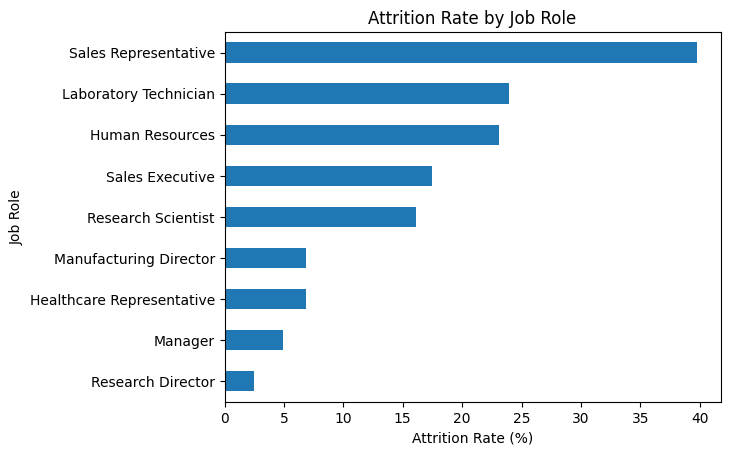

In [ ]:
#Which job roles have the highest attrition risk?
job = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

job['Yes'].sort_values().plot(kind='barh')

plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.show()

In [ ]:
#Does overtime increase attrition?
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

overtime_attrition.plot(kind='bar', stacked=True)

plt.ylabel('Percentage (%)')
plt.title('Overtime vs Attrition')
plt.legend(title='Attrition')
plt.show()

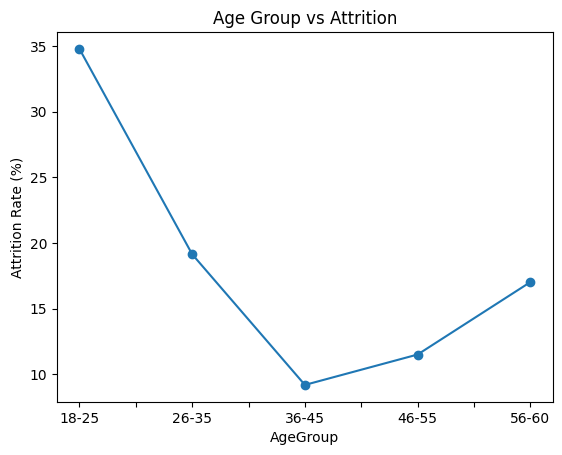

In [ ]:
#Which age group leaves the company more often?
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18,25,35,45,55,60],
    labels=['18-25','26-35','36-45','46-55','56-60']
)

age = pd.crosstab(
    df['AgeGroup'],
    df['Attrition'],
    normalize='index'
) * 100

age['Yes'].plot(marker='o')

plt.title("Age Group vs Attrition")
plt.ylabel("Attrition Rate (%)")
plt.show()

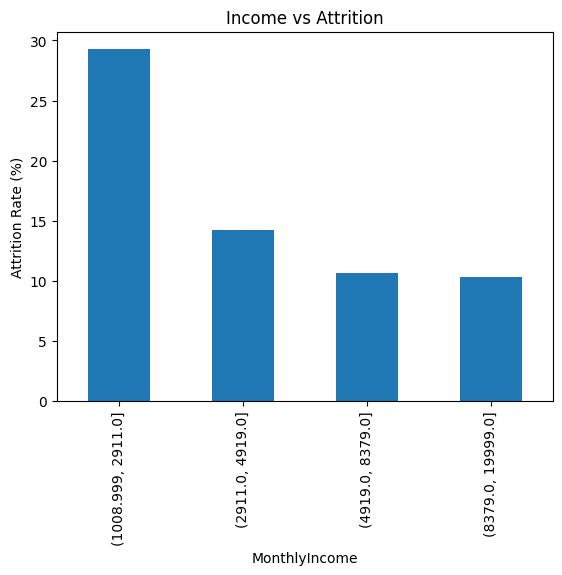

In [ ]:
#Does salary influence attrition?
income = pd.crosstab(
    pd.qcut(df['MonthlyIncome'],4),
    df['Attrition'],
    normalize='index'
) * 100

income['Yes'].plot(kind='bar')

plt.title("Income vs Attrition")
plt.ylabel("Attrition Rate (%)")
plt.show()

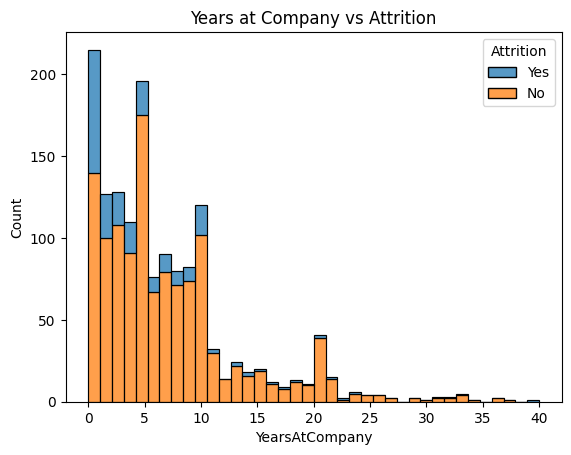

In [ ]:
#How does employee experience level influence attrition?
sns.histplot(data=df,
             x='YearsAtCompany',
             hue='Attrition',
             multiple='stack')

plt.title("Years at Company vs Attrition")
plt.show()

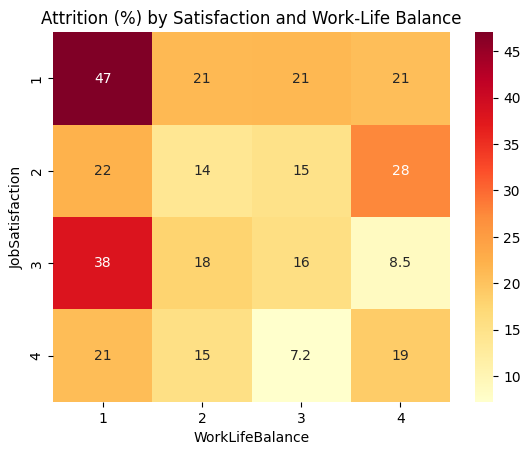

In [ ]:
#How do Job Satisfaction and Work-Life Balance affect attrition?
heat = pd.crosstab(
    df['JobSatisfaction'],
    df['WorkLifeBalance'],
    values=(df['Attrition']=="Yes"),
    aggfunc='mean'
) * 100

sns.heatmap(heat, annot=True, cmap='YlOrRd')

plt.title("Attrition (%) by Satisfaction and Work-Life Balance")
plt.show()

In [ ]:
df['Attrition']

,Attrition
0,Yes
1,No
2,Yes
3,No
4,No
...,...
1465,No
1466,No
1467,No
1468,No


In [ ]:


# SVM Model

# Create a copy to avoid modifying the original df for subsequent cells
df_processed = df.copy()

# Apply LabelEncoder to 'Attrition' for the target variable 'y'
le = LabelEncoder()
df_processed['Attrition'] = le.fit_transform(df_processed['Attrition'])
y = df_processed['Attrition']

# Drop 'Attrition' from the feature set
X_features = df_processed.drop('Attrition', axis=1)

# Apply one-hot encoding to all remaining object columns in X_features
# This ensures all categorical features in X are numerical.
X = pd.get_dummies(X_features, drop_first=True)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
#svm model creation

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred = svm.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.8843537414965986


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[244  11]
 [ 23  16]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       255
           1       0.59      0.41      0.48        39

    accuracy                           0.88       294
   macro avg       0.75      0.68      0.71       294
weighted avg       0.87      0.88      0.88       294



In [ ]:
SVC(kernel='linear')

SVC(kernel='linear')

                             Feature  Importance
46                      OverTime_Yes    0.627130
23                YearsInCurrentRole    0.443589
26  BusinessTravel_Travel_Frequently    0.416268
22                    YearsAtCompany    0.362681
24           YearsSinceLastPromotion    0.351358
37     JobRole_Laboratory Technician    0.350377
19                 TotalWorkingYears    0.349459
13                NumCompaniesWorked    0.333621
10                   JobSatisfaction    0.326301
6            EnvironmentSatisfaction    0.297900


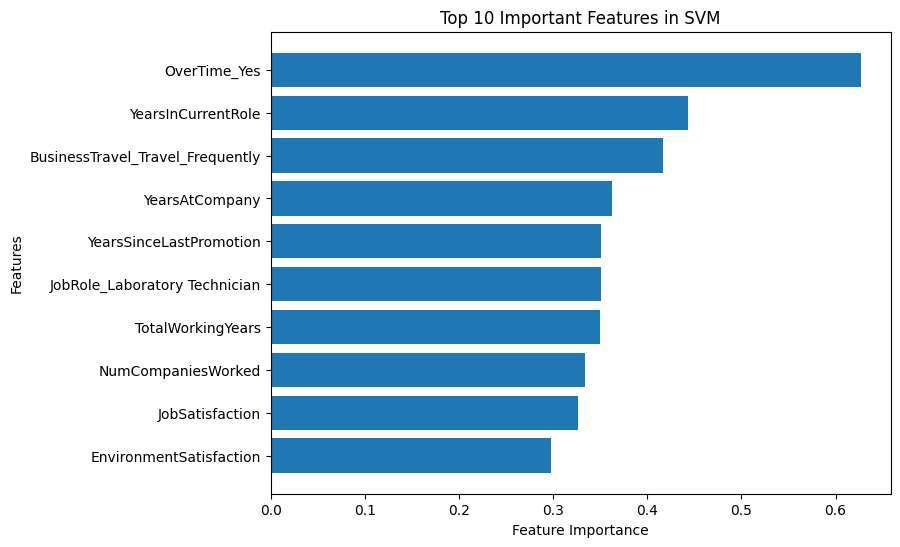

In [ ]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(svm.coef_[0])
})

# Sort descending
importance = importance.sort_values(by='Importance', ascending=False)

# Top 10 Features
top10 = importance.head(10)

print(top10)

#visualization
plt.figure(figsize=(8,6))

plt.barh(top10['Feature'], top10['Importance'])

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features in SVM")

plt.gca().invert_yaxis()

plt.show()

                          Feature  Importance
46                   OverTime_Yes    0.020748
32         EducationField_Medical    0.017347
8                  JobInvolvement    0.015986
42        JobRole_Sales Executive    0.010204
37  JobRole_Laboratory Technician    0.008503
23             YearsInCurrentRole    0.008163
6         EnvironmentSatisfaction    0.005442
19              TotalWorkingYears    0.004422
25           YearsWithCurrManager    0.004082
22                 YearsAtCompany    0.003061


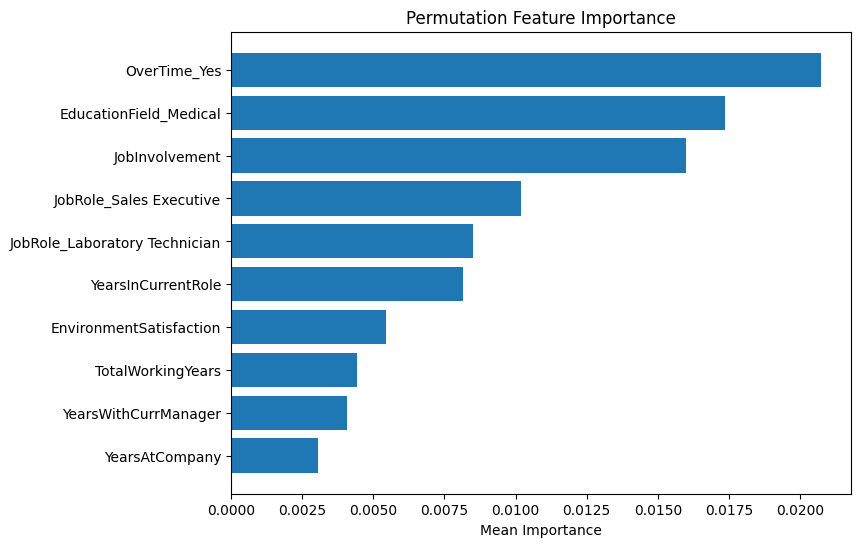

In [ ]:
#permutation importance
result = permutation_importance(
    svm,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

perm = perm.sort_values(
    by='Importance',
    ascending=False
)

print(perm.head(10))

#visualization
top10 = perm.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10['Feature'], top10['Importance'])

plt.title("Permutation Feature Importance")
plt.xlabel("Mean Importance")

plt.gca().invert_yaxis()
plt.show()

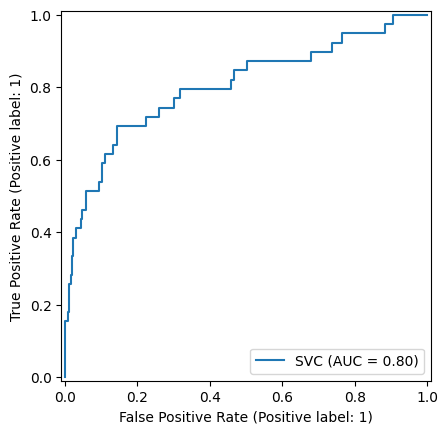

In [ ]:
#ROC --- Receiver Operating Characteristic Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    svm,
    X_test,
    y_test
)

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(svm, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.84693878 0.85034014 0.83673469 0.86394558 0.85034014]
Average Accuracy: 0.8496598639455784
